# Toy Model: Filtering

In [3]:
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import pickle
import pandas as pd

# my preferred settings
mpl.rc('lines',linewidth = 1.5)
mpl.rc('font',size = 14)
mpl.rc('axes',labelsize = 16, linewidth=1.25)
mpl.rc('xtick',labelsize = 16)
mpl.rc('ytick',labelsize = 16)
plt.rcParams['savefig.dpi'] = 400 
# enable math fonts
mpl.rc('mathtext', default = 'regular')

period_limit = 100. # days
dist_limit = 500.  # pc (nb:2000. == 200AU/0.1arcsec)
radius_limit = 6.   # Re
max_radius_error = 0.25 # fraction
from sbin import parameters

## Read in the data

### Data from Sullivan (db)

In [4]:
# read in Kendall's catalog, xmatched to all the stuff from Kepler that I need
with open('tables/kendall+kepler.pkl', 'rb') as file:
       tmp = pickle.load(file)
db = tmp[ tmp['koi_disposition']!='FALSE POSITIVE' ]

print('Binaries, all planets', len(db))
print('Binaries, unique stars', len(db['KOI'].unique()))

Binaries, all planets 401
Binaries, unique stars 291


### KOI+Gaia data

In [5]:
# read in my kois table
with open('tables/kois+gaia.pkl', 'rb') as file:
        kois = pd.read_pickle(file)

### Data from Thebault & Bonani (tb)

In [6]:
# confirmed planets only
allbin = Table.read('tables/plan_allbinall.mrt', format='ascii.mrt').to_pandas()

mask = allbin['Alternate'].str.match(r'^KOI\d+(?:\.\d+)?$', na=False)
tmp = allbin.loc[mask].copy()
tmp['KOI'] = tmp['Alternate'].str.extract(r'KOI0*(\d+)', expand=False).astype(int)
tb=tmp.merge(kois, on='KOI', suffixes=['','_y'])

print('Binaries, all planets', len(tb))
print('Binaries, unique stars', len(tb['KOI'].unique()))

Binaries, all planets 429
Binaries, unique stars 265


In [7]:
tmp = tb[tb['semi-major']<200.][['KOI']].drop_duplicates().reset_index(drop=True)

# merge T&B and Sullivan
tmp = tmp.merge(db[['KOI','SepAU']].drop_duplicates().reset_index(drop=True), on='KOI', how='left')

# only 5 of the close-separation binaries in T&B are not from Sullivan+23,24
check = tmp.loc[~np.isfinite(tmp['SepAU']),'KOI']

check

0      824
1     1257
6     2169
10    2032
81     387
Name: KOI, dtype: int64

## Merge Sullivan and T&B, Calc snowline

In [8]:
db_sub = db[['KOI','kepoi_name','Teff1', 'Teff2', 
             'distance', 'SepAU', 'ruwe',
             'koi_disposition', 'koi_period', 'koi_prad', 'Rppri']].copy()
db_sub['steff_adopt'] = db['Teff1']
db_sub['prad_adopt'] = db['Rppri']
db_sub['e_prad_adopt'] = db['e_Rppri']

lum = (db['Teff1'].astype(float)/5777.)**4 * db['Rstar1']**2
db_sub['mass_pri_adopt'] = lum**0.25
lum = (db['Teff2'].astype(float)/5777.)**4 * (db['Rstar2_Rstar1']*db['Rstar1'])**2
db_sub['mass_sec_adopt'] = lum**0.25

tb_sub = tb[['KOI','kepoi_name', 'Mass', 'Mass_1',
             'ruwe',
            'koi_disposition', 'koi_period', 'koi_prad']].copy()
tb_sub['steff_adopt'] = tb['teff']
tb_sub['prad_adopt'] = tb['koi_prad']
tb_sub['e_prad_adopt'] = np.max([tb['koi_prad_err1'], np.abs(tb['koi_prad_err2'])], axis=0)
tb_sub['mass_pri_adopt'] = tb['Mass']
tb_sub['mass_sec_adopt'] = tb['Mass_1']
tb_sub['distance'] = 1000./tb['parallax']
tb_sub['SepAU'] = tb['semi-major']


binaries = db_sub.merge(
    tb_sub,
    on=["KOI", "kepoi_name"],                
    how="outer",
    suffixes=("_A", "_B"))

overlap = [col for col in db_sub.columns if col in tb_sub.columns and col != "KOI" and col != "kepoi_name"] 
for col in overlap:
    binaries[col] = binaries[f"{col}_A"].combine_first(binaries[f"{col}_B"])
    # drop the two temporary columns
    binaries.drop(columns=[f"{col}_A", f"{col}_B"], inplace=True)



q = binaries['mass_pri_adopt']/binaries['mass_sec_adopt']
RL = 0.49*q**(2/3)/(0.6*q**(2/3)+np.log(1+q**(1/3))) # verified against https://dev.adsabs.harvard.edu/scan/
disk = RL * binaries['SepAU']

binaries['DiskAU'] = disk
binaries['SnowAU'] = 0.00465*0.5*(binaries['steff_adopt']/170.)**2 # for T_eq = 170K

binaries

,KOI,kepoi_name,Teff1,Teff2,Rppri,Mass,Mass_1,distance,SepAU,ruwe,koi_disposition,koi_period,koi_prad,steff_adopt,prad_adopt,e_prad_adopt,mass_pri_adopt,mass_sec_adopt,DiskAU,SnowAU
0,42,K00042.01,6640.0,4771.0,2.28,NaN,NaN,147.203880,244.358436,0.969059,CONFIRMED,17.833678,2.43,6640.0,2.28,0.14,1.348264,0.695891,106.827692,3.547001
1,112,K00112.01,6256.0,5506.0,3.55,NaN,NaN,581.176305,63.929393,13.556035,CONFIRMED,51.079265,2.75,6256.0,3.55,0.72,1.148094,0.876828,25.728899,3.148608
2,112,K00112.02,6256.0,5506.0,1.49,NaN,NaN,581.176305,63.929393,13.556035,CONFIRMED,3.709214,1.16,6256.0,1.49,0.30,1.148094,0.876828,25.728899,3.148608
3,162,K00162.01,6148.0,5622.0,3.72,1.030,0.92,882.904445,256.042282,NaN,CONFIRMED,14.006404,3.11,6148.0,3.72,0.83,1.104946,0.909931,101.351683,3.040835
4,163,K00163.01,5290.0,5015.0,2.71,0.870,0.82,471.761732,575.549327,1.589827,CONFIRMED,11.119903,2.08,5290.0,2.71,0.26,0.799863,0.741412,221.878348,2.251316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,775,K00775.02,NaN,NaN,NaN,0.624,0.50,319.659291,9842.000000,1.028861,CONFIRMED,7.877416,2.16,4126.0,2.16,0.11,0.624000,0.500000,3919.471245,1.369568
551,775,K00775.03,NaN,NaN,NaN,0.624,0.50,319.659291,9842.000000,1.028861,CONFIRMED,36.445400,1.99,4126.0,1.99,0.09,0.624000,0.500000,3919.471245,1.369568
552,587,K00587.01,NaN,NaN,NaN,0.850,0.50,534.658551,9861.000000,0.967129,CONFIRMED,14.034903,2.41,5258.0,2.41,0.32,0.850000,0.500000,4196.341616,2.224161
553,2210,K02210.01,NaN,NaN,NaN,0.810,0.50,565.026435,10517.000000,0.985003,CONFIRMED,2.888904,1.68,4895.0,1.68,0.10,0.810000,0.500000,4430.506900,1.927660


## Single-star hosts: Basic filtering 

Not a known binary, not a false positive, has a parallax, has RUWE<1.2

### KOIs

In [9]:
kois_less = kois[ (~kois['kepoi_name'].isin(binaries['kepoi_name'])) & \
                 (kois['koi_disposition']!='FALSE POSITIVE') & \
                 np.isfinite(kois['parallax']) & \
                 (kois['ruwe']<1.2) ].copy()

# at least one CONFIRMED per KOI 
has_confirmed = (
    kois_less.groupby('KOI')['koi_disposition']
    .transform(lambda s: (s == 'CONFIRMED').any())
)

kois_less['has_confirmed'] = has_confirmed

print('KOIs, singles', len(kois_less))
print('KOIs, unique stars', len(kois_less['KOI'].unique()))

KOIs, singles 3861
KOIs, unique stars 2944


### CKS Sample

In [10]:
tmp = Table.read('tables/fulton2018.vot').to_pandas()
tmp['kepoi_name'] = tmp['KOI']
tmp['KOI'] = tmp['kepoi_name'].str.extract(r'K0*(\d+)\.\d+')[0].astype(int)
cks=tmp.merge(kois, on='kepoi_name', suffixes=['','_y'])


cks_less = cks[ (~cks['kepoi_name'].isin(binaries['kepoi_name'])) & \
                (cks['koi_disposition']!='FALSE POSITIVE') & \
                 np.isfinite(cks['parallax']) & \
                 (cks['ruwe']<1.2) &  (cks['koi_kepmag']<14.2) ]

print('CKS, all planets', len(cks_less))
print('CKS, unique stars', len(cks_less['KOI'].unique()))

CKS, all planets 962
CKS, unique stars 664


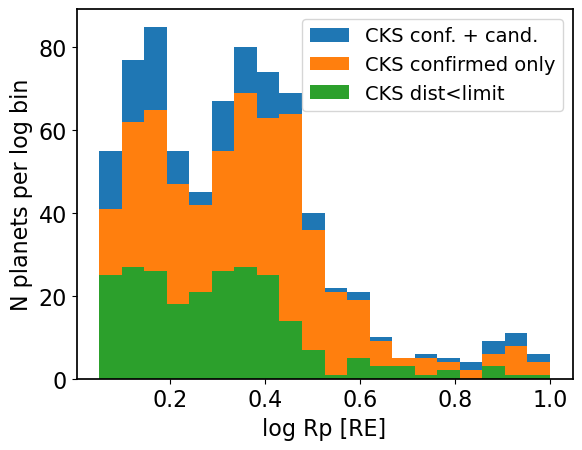

In [11]:
plt.hist(np.log10(cks_less['Rp']), range=(0.05,1), bins=20,
        label='CKS conf. + cand.')
plt.hist(np.log10(cks_less['Rp'][cks_less['koi_disposition']=='CONFIRMED']), 
         range=(0.05,1), bins=20,
         label='CKS confirmed only')
plt.hist(np.log10(cks_less['Rp'][1000./cks_less['parallax']<dist_limit]), range=(0.05,1), bins=20,
        label='CKS dist<limit')
plt.xlabel('log Rp [RE]')
plt.ylabel('N planets per log bin')
plt.legend()

## Define subsamples

### Define and apply filters

Limit on planet period and distance to star

In [12]:

# filter the sample
db_lim = ((binaries['koi_period'] < period_limit) & \
        (binaries['distance'] < dist_limit))

kois_lim = (kois_less['koi_period'] < period_limit)  & \
        (1000./kois_less['parallax'] < dist_limit)
cks_lim = (cks_less['Per'] < period_limit) & \
        (1000./cks_less['parallax'] < dist_limit)
       

# filter the binaries
binaries_filtered = binaries[(binaries['prad_adopt'] < radius_limit) & db_lim].copy()
rad_good = binaries_filtered['e_prad_adopt']/binaries_filtered['prad_adopt'] < max_radius_error

# filter the KOIs
kois_filtered_cc = kois_less[(kois_less['koi_prad']<radius_limit) & kois_lim].copy()
kois_cc_rad_good = np.max([kois_filtered_cc['koi_prad_err1'], np.abs(kois_filtered_cc['koi_prad_err2'])], axis=0)/kois_filtered_cc['koi_prad'] < max_radius_error

# Filter CKS
cks_filtered = cks_less[(cks_less['Rp']<radius_limit) & cks_lim].copy()
cks_rad_good = (cks_filtered['koi_prad_err1'] - cks_filtered['koi_prad_err2'])/cks_filtered['Rp']/2. < max_radius_error



In [13]:
len(binaries['KOI'][np.isnan(binaries['parallax'])].unique())

KeyError: 'parallax'

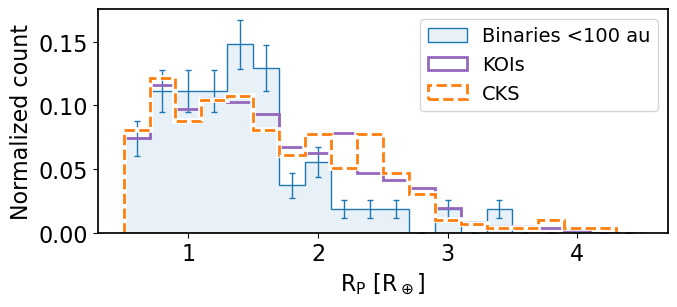

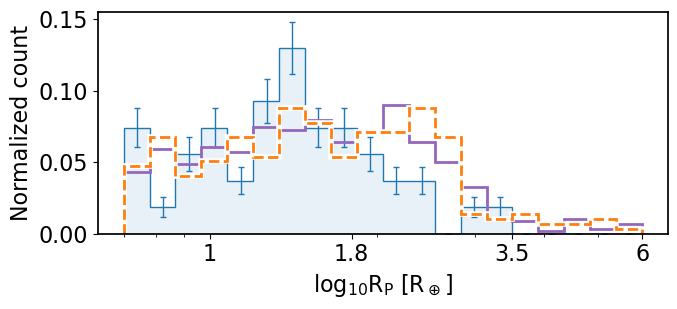

In [14]:

for option in ['linear','log']:

    nbins=20

    if option=='linear':
        histrange=[0.5,4.5]
        bin_edges = np.linspace(histrange[0], histrange[1], nbins + 1)
    else:
        histrange=[np.log10(0.7),np.log10(6)]
        bin_edges = np.logspace(histrange[0], histrange[1], nbins + 1)
        
    bin_width = np.diff(bin_edges)
    bin_center = bin_edges[:-1]+bin_width/2.
        
    fig, axes = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)

    close = binaries_filtered['SepAU']<100.
    nplanets = len(binaries_filtered[rad_good & close])
    ww = 1./np.full(nplanets, nplanets, dtype=float)
    # planets with good radii in binary systems with rho<100 au and planet period < 100 days
    y, _, _ = plt.hist(binaries_filtered['Rppri'][rad_good & close], 
                  bins=bin_edges, weights=ww,
             histtype='stepfilled', edgecolor='#1f77b4', facecolor='#e8f1f7',
            label='Binaries <100 au')

    plt.errorbar(bin_center, y, np.sqrt(y)/len(y), ls='None', lw=1, capsize=2, c='C0')

    # compared to the kois that are at least not definite binaries with good radii and per<100 days
    nplanets = len(kois_filtered_cc[kois_cc_rad_good])
    plt.hist(kois_filtered_cc['koi_prad'][kois_cc_rad_good], 
                  bins=bin_edges,  weights = 1./np.full(nplanets, nplanets, dtype=float),
                 histtype='step', lw=2, color='C4',
            label='KOIs')

    # compared to the cks
    nplanets = len(cks_filtered[cks_rad_good])
    plt.hist(cks_filtered['Rp'][cks_rad_good], 
                 bins=bin_edges,  weights = 1./np.full(nplanets, nplanets, dtype=float),
                 histtype='step',lw=4, color='white')
    plt.hist(cks_filtered['Rp'][cks_rad_good], 
                 bins=bin_edges,  weights = 1./np.full(nplanets, nplanets, dtype=float),
                 histtype='step',lw=2, linestyle='--', color='C1',
            label='CKS')

    plt.ylabel('Normalized count')
    
    if option=='linear':
        plt.legend()
        plt.xlabel('$R_P$ [$R_\oplus$]')        
    else:
        plt.xlabel('$log_{10} R_P$ [$R_\oplus$]')  
        plt.xscale('log')
        
        custom_log_ticks = [1, 1.8, 3.5, 6]
        plt.gca().set_xticks(custom_log_ticks)
        plt.gca().set_xticklabels([str(t) for t in custom_log_ticks])
        
    plt.tight_layout()
    #plt.savefig('prad-'+option+'.png')

    plt.xlim()
    
    
    

In [15]:
bundle = {
    "binaries_filtered": binaries_filtered,      # pandas DataFrame
    "kois_filtered_cc": kois_filtered_cc,  # pandas DataFrame
    "binaries_unfiltered": binaries,  # pandas DataFrame
}

with open("filtered_data.pkl", "wb") as f:
    pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)


## Get numbers for paper

In [ ]:
def calc_statistics(catalog, prad_col = 'Rp', star_col='KOI', MTPS=False):
    
    n_planets = float(len(catalog))
    print( "Number of planets: ", int(n_planets))
    print( "Number of stars: ", len(catalog[star_col].unique()))
    
    n_SEs = float(len(catalog.loc[catalog[prad_col]<parameters.radius_valley]))
    print("Frac super-Earths/n_planets: ", n_SEs/n_planets, "+-", np.sqrt(n_SEs)/n_planets)
    
    if MTPS:
        planet_counts = catalog.groupby(star_col).size().reset_index(name='n_planets')
        stps = len(planet_counts.loc[planet_counts['n_planets']==1])
        mtps = len(planet_counts.loc[planet_counts['n_planets']>1])
        print("Frac MTPS: ", mtps, stps, mtps/(stps+mtps), "+-", np.sqrt(mtps)/(stps+mtps))


# ----------------------------------------------
# Print all the samples and sub-samples
# ----------------------------------------------

        
print("BINARIES\n\n All")

print("\n Close BINARIES")
calc_statistics(binaries_filtered[close], prad_col='prad_adopt', MTPS=True)

print("\n Wide BINARIES")
calc_statistics(binaries_filtered[~close], prad_col='prad_adopt', MTPS=True)


print("\n\nSINGLE KOIS")
calc_statistics(kois_filtered_cc, prad_col='koi_prad', MTPS=True)

print("\nSINGLE CKS")
calc_statistics(cks_filtered, MTPS=True)

BINARIES

 All

 Close BINARIES
Number of planets:  61
Number of stars:  37
Frac super-Earths/n_planets:  0.7540983606557377 +- 0.11118573742828308
Frac MTPS:  13 24 0.35135135135135137 +- 0.097447331769297

 Wide BINARIES
Number of planets:  139
Number of stars:  91
Frac super-Earths/n_planets:  0.539568345323741 +- 0.06230398588377257
Frac MTPS:  24 67 0.26373626373626374 +- 0.05383493940182808


SINGLE KOIS
Number of planets:  644
Number of stars:  436
Frac super-Earths/n_planets:  0.6335403726708074 +- 0.031364922168826324
Frac MTPS:  139 297 0.31880733944954126 +- 0.027040885602182558

SINGLE CKS
Number of planets:  323
Number of stars:  215
Frac super-Earths/n_planets:  0.631578947368421 +- 0.044219371074568734
Frac MTPS:  73 142 0.3395348837209302 +- 0.03973955230380247


### Investigate trends

/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_5145/941619466.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,300)


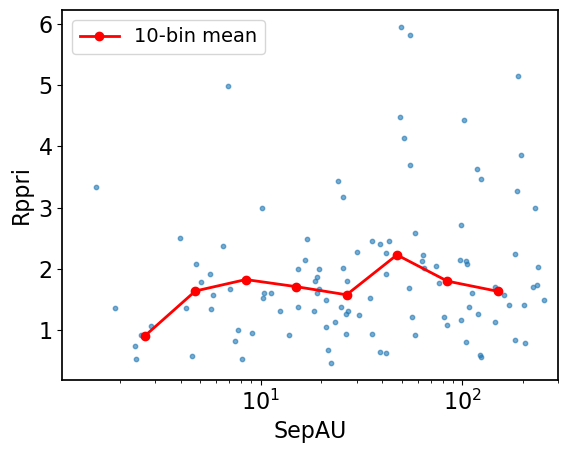

In [ ]:
# biggest planet
max_rp = binaries_filtered.loc[binaries_filtered.groupby('KOI')['prad_adopt'].idxmax()].reset_index(drop=True)

# scatter 
y = max_rp['DiskAU']/max_rp['SnowAU']
plt.scatter(y, max_rp['prad_adopt'], s=10, alpha=0.6)
plt.xscale('log')
plt.xlabel('SepAU'); plt.ylabel('Rppri')
plt.xlim(0,300)

# 10 log-spaced bins (11 edges)
#bins = np.logspace(np.log10(20), np.log10(3000), 11)
bins = np.logspace(np.log10(2), np.log10(200), 9)

# assign points to bins
bin_idx = np.digitize(y.values, bins)

# keep only points inside [bins[0], bins[-1]]
valid = (bin_idx >= 1) & (bin_idx <= len(bins) - 1)
tmp = max_rp.loc[valid, ['Rppri']].copy()
tmp['bin'] = bin_idx[valid]

# mean Rppri per bin, ensure length 10 (fill missing bins with NaN)
means = tmp.groupby('bin')['Rppri'].mean().reindex(range(1, len(bins))).values

# plot at bin centers (geometric mean of edges)
centers = np.sqrt(bins[:-1] * bins[1:])
plt.plot(centers, means, color='red', linewidth=2, marker='o', label='10-bin mean')

plt.legend()
plt.show()

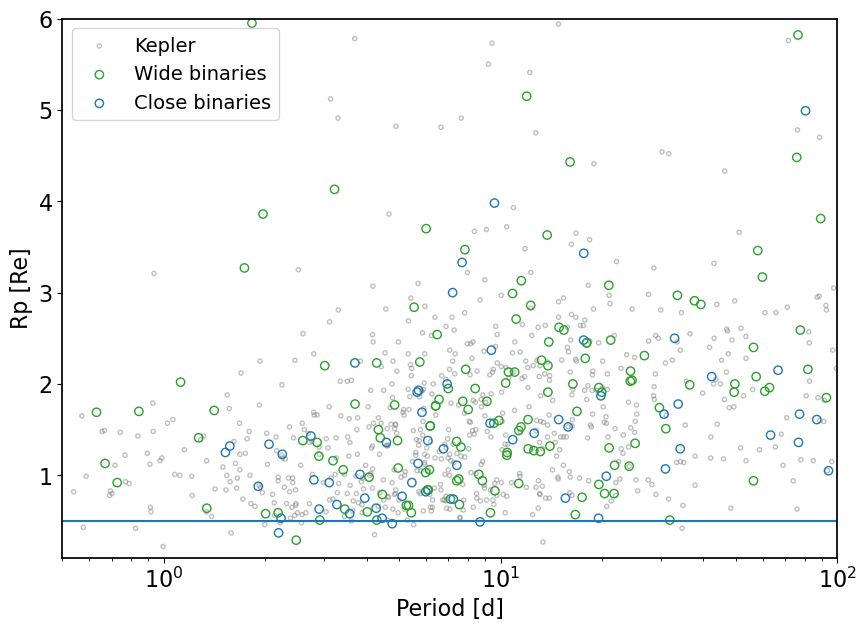

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(kois_filtered_cc['koi_period'], kois_filtered_cc['koi_prad'], marker='.',
         edgecolor='gray', alpha=0.5, lw=1, facecolor='None', label='Kepler')

plt.scatter(binaries_filtered['koi_period'][~close], binaries_filtered['prad_adopt'][~close] ,
         edgecolor='C2', facecolor='None', lw=1, label='Wide binaries')
plt.scatter(binaries_filtered['koi_period'][close], binaries_filtered['prad_adopt'][close] ,
         edgecolor='C0', lw=1, facecolor='None', label='Close binaries')


plt.xlim(0.5,100)
plt.ylim(0.1,6)
plt.axhline(0.5)
plt.xscale('log')
plt.xlabel('Period [d]')
plt.ylabel('Rp [Re]')
plt.legend()